# ISC follow-up directions

This notebook checks the follow-up directions that I'll be pursuing for the ISC paper.

## 1. Curriculum effect in visual learning: the role of readout dimensionality

We first replicate the easy-to-hard experiment results from this paper in the context of the ISC model.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv('data/easyhard_curriculum_data.csv')
# Drop the unnamed index-like column and coerce types for plotting
df = df.loc[:, [col for col in df.columns if col]].copy()
df['model'] = df['model'].astype(int)
df['acc'] = df['acc'].astype(float)


/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_91386/2039130158.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_curriculum, labels=curricula, widths=0.6, patch_artist=True,


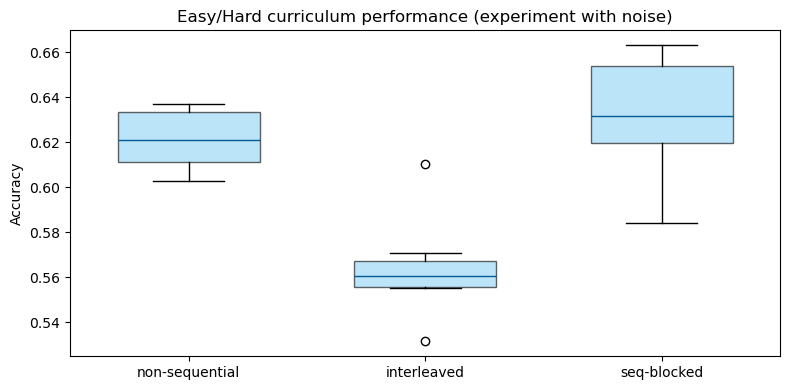

In [6]:
# Box plots: each curriculum uses the 10 model means as its data points
curriculum_order = ['non-sequential', 'interleaved', 'seq-blocked']
grouped = (df.groupby(['curriculum', 'model'])['acc']
             .mean()
             .reset_index())
available_curricula = grouped['curriculum'].unique().tolist()
curricula = [c for c in curriculum_order if c in available_curricula] or sorted(available_curricula)

fig, ax = plt.subplots(figsize=(8, 4), sharey=False)
data_by_curriculum = [grouped[grouped['curriculum'] == curriculum]['acc'] for curriculum in curricula]
ax.boxplot(data_by_curriculum, labels=curricula, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#8fd3f4', alpha=0.6),
           medianprops=dict(color='#005b96'))
ax.set_ylabel('Accuracy')
ax.set_title('Easy/Hard curriculum performance (experiment with noise)')
fig.tight_layout()
plt.show()



In [3]:
df = pd.read_csv('data/easyhard_noiseless_data.csv')
# Drop the unnamed index-like column and coerce types for plotting
df = df.loc[:, [col for col in df.columns if col]].copy()
df['model'] = df['model'].astype(int)
df['acc'] = df['acc'].astype(float)


/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_91386/698757694.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_curriculum, labels=curricula, widths=0.6, patch_artist=True,


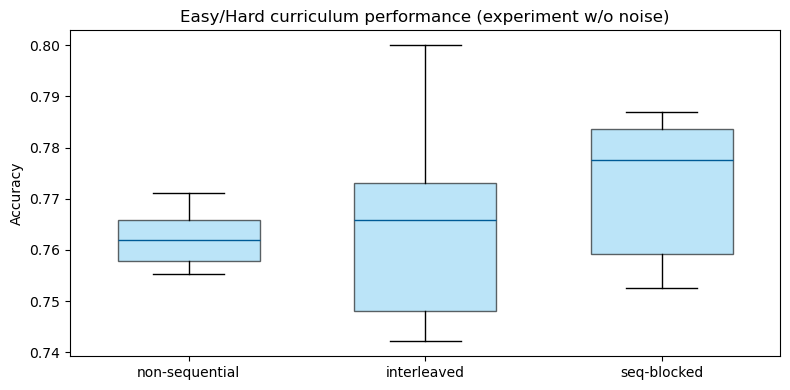

In [ ]:
# Box plots: each curriculum uses the 10 model means as its data points
curriculum_order = ['non-sequential', 'interleaved', 'seq-blocked']
grouped = (df.groupby(['curriculum', 'model'])['acc']
             .mean()
             .reset_index())
available_curricula = grouped['curriculum'].unique().tolist()
curricula = [c for c in curriculum_order if c in available_curricula] or sorted(available_curricula)

fig, ax = plt.subplots(figsize=(8, 4), sharey=False)
data_by_curriculum = [grouped[grouped['curriculum'] == curriculum]['acc'] for curriculum in curricula]
ax.boxplot(data_by_curriculum, labels=curricula, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#8fd3f4', alpha=0.6),
           medianprops=dict(color='#005b96'))
ax.set_ylabel('Accuracy')
ax.set_title('Easy/Hard curriculum performance (experiment w/o noise)')
fig.tight_layout()
plt.show()


The ranges overlapped quite a bit for $n=10$ above, so we can instead examine $n=20$.

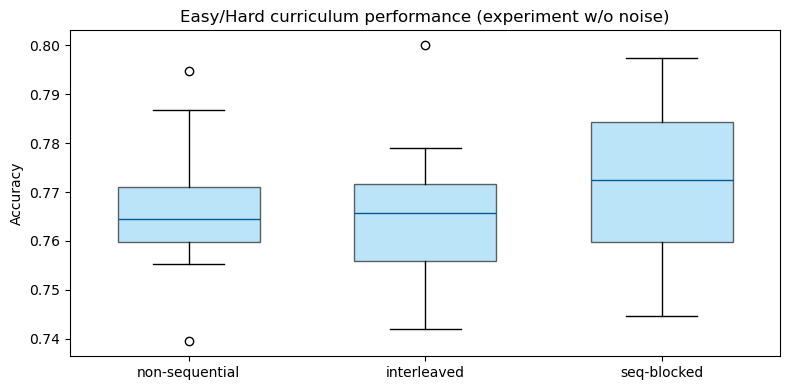

In [10]:
df = pd.read_csv('data/easyhard_noiseless_n20.csv')
# Drop the unnamed index-like column and coerce types for plotting
df = df.loc[:, [col for col in df.columns if col]].copy()
df['model'] = df['model'].astype(int)
df['acc'] = df['acc'].astype(float)

# Box plots: each curriculum uses the 10 model means as its data points
curriculum_order = ['non-sequential', 'interleaved', 'seq-blocked']
grouped = (df.groupby(['curriculum', 'model'])['acc']
             .mean()
             .reset_index())
available_curricula = grouped['curriculum'].unique().tolist()
curricula = [c for c in curriculum_order if c in available_curricula] or sorted(available_curricula)

fig, ax = plt.subplots(figsize=(8, 4), sharey=False)
data_by_curriculum = [grouped[grouped['curriculum'] == curriculum]['acc'] for curriculum in curricula]
ax.boxplot(data_by_curriculum, labels=curricula, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#8fd3f4', alpha=0.6),
           medianprops=dict(color='#005b96'))
ax.set_ylabel('Accuracy')
ax.set_title('Easy/Hard curriculum performance (experiment w/o noise)')
fig.tight_layout()
plt.show()

## 2. Modelling continual learning in humans with Hebbian context gating and exponentially decaying task signals

We next replicate the context gating from this paper, implementing slow neurons.